## 4차시 과제

**Q1. Target Encoding의 문제점을 서술하고, 이를 극복하기 위한 방법을 찾아 작성해주세요. (15점)**

In [185]:
# 인코딩된 라벨값이 각각 타겟과 관련된 의미를 가지므로 오히려 과적함될 가능성이 높다.
# 구현과 검증이 까다롭다

#극복: 인코딩 값에 랜덤 노이즈를 추가해서 특정 인코딩 값에 의존하지 않도록 할 수 있다.

**Q2. 오늘 배운 Encoding 기법 외의 다른 Encoding 기법에는 무엇이 있는지 설명과 함께 작성해주세요. (11점)**

In [186]:
# 빈도 인코딩(Frequency Encoding): 긱 카테고리 값이 데이터에 등장한 횟수로 인코딩
# 순위 인코딩(Order Encoding): 카테고리에 순서가 있는 경우, 해당 순서대로 정수 할당 ex) 사원 - 대리 - 부장 : 1 - 2 - 3

**Q3. 차원의 저주가 무엇인지 서술하고, 이를 해결하기 위한 방법과, 방법에 대한 설명 및 과정을 적어주세요. (12점)**

데이터의 차원이 증가할수록 필요한 데이터 양이 기하급수적으로 늘어나는 현상  
데이터의 양(행 = 데이터)은 동일한데, 데이터의 차원(열 = 변수개수)이 커지면 데이터의 밀도가 떨어짐  
ex) 2개의 변수만 있을때는 10개의 행만으로도 패턴을 잘 파악할 수 있지만, 10개의 변수가 있을 때는 10개의 행만으로는 패턴 파악이 어려움  

데이터의 차원을 낮춰야함 -> 주성분 분석  
고차원의 데이터에서 서로 상관관계가 있는 변수를 조합하여, 새로운 축(주성분)을 찾는 방법  
주성분은 변수들의 선형결합으로 정의되며, 데이터의 분산을 가장 많이 설명하는 방향부터 순서대로 정렬  

과정: 데이터 정규화 -> 공분산(각 변수 간 관계) 행렬 계산 -> 고유값과(주성분이 설명하는 분산 크기) 고유벡터(주성분의 방향) 계산 -> 주성분 선택(고유값이 큰 순서대로 고유벡터 정렬, 가장 큰 몇 개 주성분 선택) -> 데이터 변환

## 배운 내용을 활용하여 자유롭게 데이터 전처리, 모델 학습을 시키고 아래의 빈칸을 채워주세요.

### 자전거 수요 예측 데이터
    * year, month, day, hour
    * season: 계절
    * holiday: 1=주말을 제외한 국경일 등의 휴일, 0=휴일이 아닌 날
    * workingday: 1=주말 및 휴일이 아닌 주중, 0=주말 및 휴일
    * weather: 날씨
    * temp: 온도(섭씨)
    * atemp: 체감온도(섭씨)
    * humidity: 상대습도
    * windspeed: 풍속
    * registered: 사전에 등록된 사용자가 대여한 횟수
    * count: 대여 횟수 (target)

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('./data/bike_train.csv')
test_df = pd.read_csv('./data/bike_test.csv')

display( train_df, test_df )

,year,month,day,hour,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,registered,count
0,2012,3,13,18,봄,0,1,"맑음, 약간 구름 낀 흐림",28.70,31.820,34.0,19.9995,638,734
1,2012,4,16,22,여름,1,0,"맑음, 약간 구름 낀 흐림",27.88,31.820,51.0,16.9979,179,214
2,2011,12,9,21,겨울,0,1,"맑음, 약간 구름 낀 흐림",12.30,16.665,75.0,0.0000,131,140
3,2011,8,8,19,가을,0,1,"맑음, 약간 구름 낀 흐림",33.62,37.120,43.0,7.0015,352,416
4,2011,10,4,7,겨울,0,1,"맑음, 약간 구름 낀 흐림",17.22,21.210,82.0,19.0012,298,309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7615,2011,1,15,0,봄,0,0,"맑음, 약간 구름 낀 흐림",7.38,12.120,55.0,0.0000,25,28
7616,2011,8,1,11,가을,0,1,"맑음, 약간 구름 낀 흐림",36.08,38.635,32.0,11.0014,66,119
7617,2012,2,5,22,봄,0,0,"맑음, 약간 구름 낀 흐림",10.66,13.635,60.0,7.0015,182,191
7618,2012,12,13,12,겨울,0,1,"맑음, 약간 구름 낀 흐림",14.76,16.665,40.0,16.9979,252,282


,year,month,day,hour,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,registered
0,2011,10,7,20,겨울,0,1,"맑음, 약간 구름 낀 흐림",22.14,25.760,49.0,0.0000,167
1,2011,4,4,14,여름,0,1,"안개, 안개 + 흐림",30.34,32.575,27.0,32.9975,76
2,2012,2,18,7,봄,0,0,"맑음, 약간 구름 낀 흐림",9.84,14.395,70.0,0.0000,33
3,2012,5,12,3,여름,0,0,"맑음, 약간 구름 낀 흐림",19.68,23.485,59.0,0.0000,20
4,2012,5,12,6,여름,0,0,"맑음, 약간 구름 낀 흐림",17.22,21.210,67.0,6.0032,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3261,2012,11,15,6,겨울,0,1,"안개, 안개 + 흐림",12.30,14.395,65.0,16.9979,146
3262,2011,4,15,21,여름,1,0,"안개, 안개 + 흐림",16.40,20.455,76.0,19.9995,77
3263,2011,10,9,11,겨울,0,0,"맑음, 약간 구름 낀 흐림",25.42,31.060,53.0,6.0032,234
3264,2011,12,7,18,겨울,0,1,"가벼운 눈, 가벼운 비 + 천둥",16.40,20.455,NaN,19.9995,48


**Q4. 결측치가 있는지 확인하고 있다면 원하는 방식으로 처리하고 왜 그렇게 처리했는지 이유를 서술하세요. (8점)** 

In [188]:
train_df.info() # temp, atemp, humidity 열 결측값 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        7620 non-null   int64  
 1   month       7620 non-null   int64  
 2   day         7620 non-null   int64  
 3   hour        7620 non-null   int64  
 4   season      7620 non-null   object 
 5   holiday     7620 non-null   int64  
 6   workingday  7620 non-null   int64  
 7   weather     7620 non-null   object 
 8   temp        7587 non-null   float64
 9   atemp       7418 non-null   float64
 10  humidity    7528 non-null   float64
 11  windspeed   7620 non-null   float64
 12  registered  7620 non-null   int64  
 13  count       7620 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 833.6+ KB


In [189]:
test_df.info() # temp, atemp, humidity 열 결측값 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3266 entries, 0 to 3265
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        3266 non-null   int64  
 1   month       3266 non-null   int64  
 2   day         3266 non-null   int64  
 3   hour        3266 non-null   int64  
 4   season      3266 non-null   object 
 5   holiday     3266 non-null   int64  
 6   workingday  3266 non-null   int64  
 7   weather     3266 non-null   object 
 8   temp        3244 non-null   float64
 9   atemp       3157 non-null   float64
 10  humidity    3235 non-null   float64
 11  windspeed   3266 non-null   float64
 12  registered  3266 non-null   int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 331.8+ KB


Text(0.5, 1.0, 'humidity')

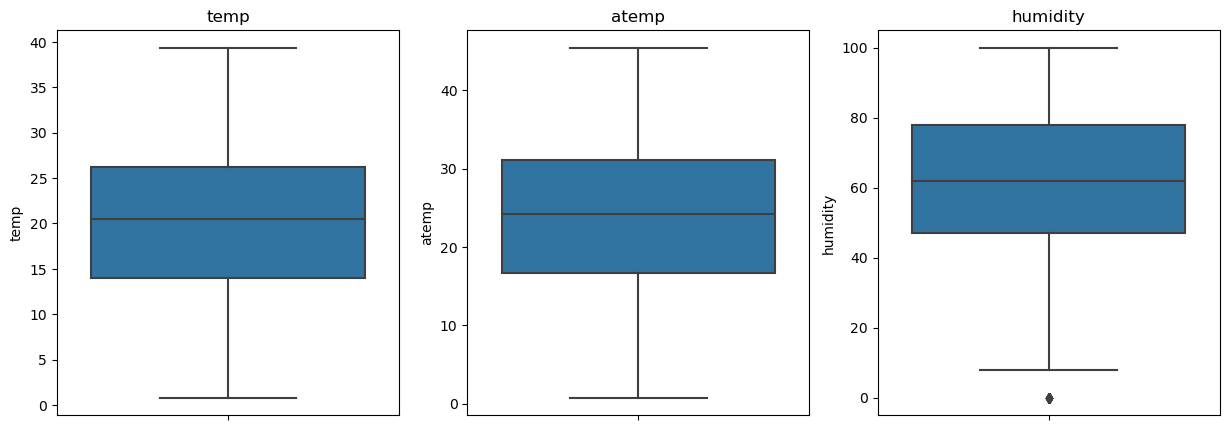

In [190]:
# 이상치 확인
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(ax=axs[0], y=train_df['temp'])
axs[0].set_title('temp')

sns.boxplot(ax=axs[1], y=train_df['atemp'])
axs[1].set_title('atemp')

sns.boxplot(ax=axs[2], y=train_df['humidity'])
axs[2].set_title('humidity')


In [191]:
# 각 중앙값, 평균, 최빈값 확인
print(train_df['temp'].median(), train_df['temp'].mean())
print(train_df['temp'].mode())

print('--------------------------------------------------------------------')

print(train_df['atemp'].median(), train_df['atemp'].mean())
print(train_df['atemp'].mode())

print('--------------------------------------------------------------------')

print(train_df['humidity'].median(), train_df['humidity'].mean())
print(train_df['humidity'].mode())

20.5 20.220181890075132
0    14.76
Name: temp, dtype: float64
--------------------------------------------------------------------
24.24 23.614667026152603
0    31.06
Name: atemp, dtype: float64
--------------------------------------------------------------------
62.0 61.899840595111584
0    88.0
Name: humidity, dtype: float64


In [192]:
# 각 이상치를 확인했을때 temp, atemp는 평균값, 이상치가 있는 humidity는 중앙값으로 대체 (최빈값은 연속형이므로 제외)
train_df['temp'] = train_df['temp'].fillna(train_df['temp'].mean())
train_df['atemp'] = train_df['atemp'].fillna(train_df['atemp'].mean())
train_df['humidity'] = train_df['humidity'].fillna(train_df['humidity'].median())

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7620 entries, 0 to 7619
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        7620 non-null   int64  
 1   month       7620 non-null   int64  
 2   day         7620 non-null   int64  
 3   hour        7620 non-null   int64  
 4   season      7620 non-null   object 
 5   holiday     7620 non-null   int64  
 6   workingday  7620 non-null   int64  
 7   weather     7620 non-null   object 
 8   temp        7620 non-null   float64
 9   atemp       7620 non-null   float64
 10  humidity    7620 non-null   float64
 11  windspeed   7620 non-null   float64
 12  registered  7620 non-null   int64  
 13  count       7620 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 833.6+ KB


**Q5. 이상치가 있는지 확인하고 있다면 원하는 방식으로 처리하고 왜 그렇게 처리했는지 이유를 서술하세요. (8점)** 

<Axes: ylabel='humidity'>

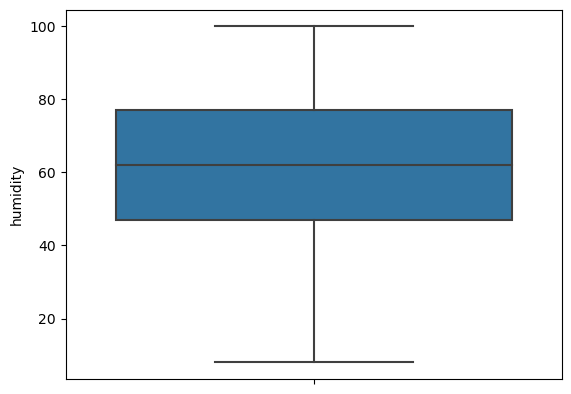

In [193]:
# 위에 박스플롯 참고, 이상치가 별로 없으므로 바로 제거함
def get_outlier(df=None,column=None,weight=1.5):  
    
    column_x = df[column]
   
    # 1/4 분위와 3/4 분위 지점을 np.percentile로 구함
    quantile_25 = np.percentile(column_x.values,25)
    quantile_75 = np.percentile(column_x.values,75)
    
    
    # IQR을 구하고 IQR에 1.5를 곱해 최댓값과 최솟값 지점 구함
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    
    # 최댓값보다 크거나, 최솟값보다 작은 값을 이상치 데이터로 설정하고 Dataframe index 반환
    outlier_index = column_x[(column_x < lowest_val) | (column_x > highest_val)].index
    return outlier_index

train_df = train_df.drop(get_outlier(df = train_df, column = 'humidity'), axis = 0)
sns.boxplot(data = train_df, y = 'humidity')

In [194]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7602 entries, 0 to 7619
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        7602 non-null   int64  
 1   month       7602 non-null   int64  
 2   day         7602 non-null   int64  
 3   hour        7602 non-null   int64  
 4   season      7602 non-null   object 
 5   holiday     7602 non-null   int64  
 6   workingday  7602 non-null   int64  
 7   weather     7602 non-null   object 
 8   temp        7602 non-null   float64
 9   atemp       7602 non-null   float64
 10  humidity    7602 non-null   float64
 11  windspeed   7602 non-null   float64
 12  registered  7602 non-null   int64  
 13  count       7602 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 890.9+ KB


**Q6. 범주형 변수를 원하는 방식으로 처리하고 왜 그렇게 처리했는지 이유를 서술하세요. (8점)** 

In [195]:
# weather, season 모두 각각 독립적으로 다루기 위해 원-핫 인코딩 처리
print(train_df['weather'].unique())
print(train_df['season'].unique())

['맑음, 약간 구름 낀 흐림' '안개, 안개 + 흐림' '가벼운 눈, 가벼운 비 + 천둥' '심한 눈/비, 천둥/번개']
['봄' '여름' '겨울' '가을']


In [196]:
train_df = pd.get_dummies(train_df, columns = ['season'], prefix = 's')
train_df = pd.get_dummies(train_df, columns = ['weather'], prefix = 'w')

**Q7. 수치형 변수들의 분포를 확인하고 적절한 scaling 혹은 transform을 수행한 후, 왜 그렇게 처리했는지 이유를 서술하세요. (12점)** 

In [197]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import Normalizer

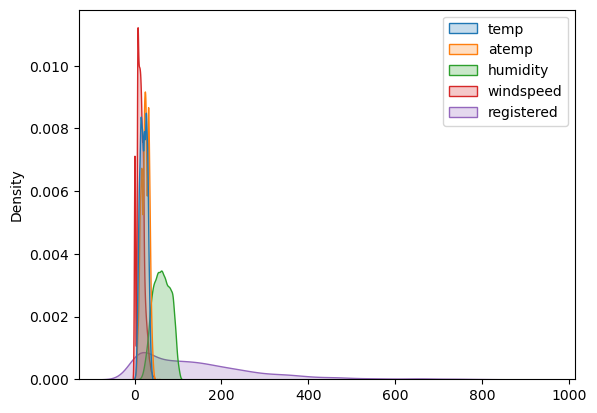

In [198]:
#스케일링 전
train_num = train_df[['temp','atemp','humidity','windspeed','registered']]

sns.kdeplot(data = train_num[['temp','atemp','humidity','windspeed','registered']], shade = True)
plt.show()

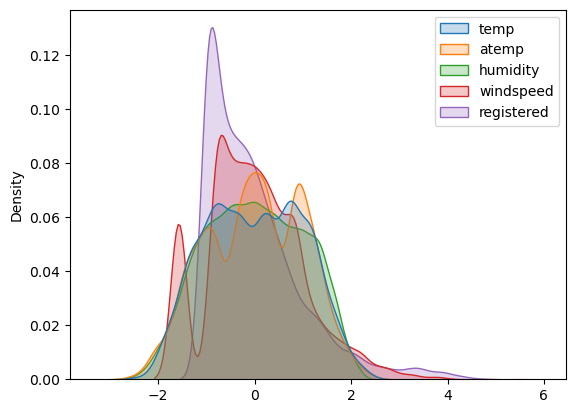

In [199]:
# 온도와 습도 풍속 등은 서로 다른 범위를 가지므로 직접비교하기 위해 정규화 실행
#스케일링 후 분포
scaler = StandardScaler()

train_df[['temp','atemp','humidity','windspeed','registered']] = scaler.fit_transform(train_num)

sns.kdeplot(data = train_df[['temp','atemp','humidity','windspeed','registered']], shade = True)
plt.show()

**Q8. 해당 데이터에 가장 적절한 PCA 방법을 적용하고 이유를 서술하세요. 만약, PCA가 필요없다고 판단했다면 그 근거를 적어주세요. (14점)** 

In [202]:
# 타겟값 삭제하고 설명력이 90%이상인 변수들 뽑음
# 원핫인코딩으로 피처가 늘어났으므로 차원축소 진행
train_2df = train_df.drop('count', axis=1).copy()
from sklearn.decomposition import PCA
def getPCA(df):
    max_col = df.shape[1]
    pca = PCA(n_components=max_col, random_state=0).fit(df)

    cumsum = np.cumsum(pca.explained_variance_ratio_) 
    num_col = np.argmax(cumsum > 0.9) + 1

    pca = PCA(n_components = num_col, random_state=0).fit_transform(df)
    return pd.DataFrame(pca)   

train_pca = getPCA(train_2df)

**Q9. 적절한 모델을 선택하여 모델을 학습시키고 왜 해당 모델을 선택했는지 이유를 적어주세요. (12점)**

In [204]:
# 설명력 높은 변수들을 뽑았으므로 회귀분석 실시
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

model = LinearRegression()

model.fit(train_pca, train_df['count'])


LinearRegression()